# LIBRARY

In [38]:
%cd /home/apolo/PhD/MonoKAN_tests/MonoKAN/Notebooks/
## Autorreload all the files
%load_ext autoreload
%autoreload 2
import time
import psutil
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.io.arff import loadarff
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import mean_squared_error, accuracy_score#, root_mean_squared_error
## Import every file in ../Scripts/
import os
import sys
sys.path.append('../Scripts')
sys.path.append('MonoKAN/Scripts/')
sys.path.append('MonoKAN/loaders/')
import KANLayer
import KAN
import spline
import utils
import importlib
import CustomELU
import grid_search
importlib.reload(KANLayer)
importlib.reload(KAN)
importlib.reload(spline)
importlib.reload(utils)
importlib.reload(CustomELU)
importlib.reload(grid_search)

from KANLayer import KANLayer
from KAN import KAN
from CustomELU import CustomELU
from grid_search import grid_search

import torch.nn as nn
import torch
import torch.nn as nn

# from mono_dense_keras.experiments import (
#     create_tuner_stats,
#     find_hyperparameters,
#     get_train_n_test_data,
# )
#torch.set_printoptions(sci_mode=False, precision=3)
print("Device", torch.cuda.is_available())

## Ignore future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)



[Errno 2] No such file or directory: '/home/apolo/PhD/MonoKAN_tests/MonoKAN/Notebooks/'
/home/jovyan/MonoKAN/Notebooks
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device True


## Utils

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import colors

# Define a normalization object for consistent contour levels
norm = colors.Normalize(vmin=-0.3, vmax=1)

def plot_model_contour_torch(model, df, var1, var2, num_keypoints=100, show_points=True, 
                              point_alpha=0.6, name='', labeled_points=None, labels=None):
    """
    Plot model contour with optional labeled points (A, B, C, ...) and custom labels.

    Parameters:
        model: torch model
        df: pandas DataFrame
        var1, var2: variables to use for the x and y axes
        num_keypoints: resolution of the grid
        show_points: whether to plot the data points from df
        point_alpha: alpha for the points
        name: if provided, save the plot with this name
        labeled_points: list of tuples (x, y) to be labeled
        labels: optional list of custom labels for each point
    """
    # Generate grid
    x = np.linspace(df[var1].min(), df[var1].max(), num_keypoints)
    y = np.linspace(df[var2].min(), df[var2].max(), num_keypoints)
    x_grid, y_grid = np.meshgrid(x, y)
    
    # Prepare model input
    positions = np.vstack([x_grid.ravel(), y_grid.ravel()]).T
    positions_tensor = torch.tensor(positions, dtype=torch.float32)
    
    # Predict
    with torch.no_grad():
        predictions = model(positions_tensor).numpy()
    grid_predictions = predictions.reshape(x_grid.shape)
    
    # Plotting
    plt.figure(figsize=(10, 8))
    plt.rcParams['font.family'] = ['serif']
    
    contourf = plt.contourf(
        x_grid, y_grid, grid_predictions,
        cmap='mako', norm=norm,
        levels=np.linspace(0, 1, 11), alpha=0.9
    )
    
    contour = plt.contour(
        x_grid, y_grid, grid_predictions,
        colors='black', linewidths=0.5,
        levels=np.linspace(0, 1, 6)
    )
    plt.clabel(contour, inline=True, fontsize=10, fmt="%.2f")
    
    if show_points:
        plt.scatter(
            df[var1], df[var2],
            c='white', edgecolor='black',
            s=50, alpha=point_alpha,
            label='Data points'
        )
        plt.legend(loc='lower right', fontsize=14)

    # Map var names to readable labels
    var_name_map = {
        'in1': 'Psychometric Test 1',
        'in2': 'Psychometric Test 2'
    }

    xlabel_pretty = var_name_map.get(var1, var1)
    ylabel_pretty = var_name_map.get(var2, var2)

    # Plot labeled points A, B, C... or with custom labels
    if labeled_points:
        if labels and len(labels) != len(labeled_points):
            raise ValueError("The number of labels must match the number of labeled_points.")
        for i, (x_pt, y_pt) in enumerate(labeled_points):
            label = labels[i] if labels else chr(65 + i)  # Use provided or fallback to A, B, C...
            plt.plot(x_pt, y_pt, 'ro', markersize=10, zorder=3)
            plt.text(x_pt + 0.02, y_pt + 0.02, label,
                     fontsize=22, fontweight='bold', color='red', zorder=3)
    
    # Colorbar
    cbar = plt.colorbar(contourf)
    cbar.ax.set_ylabel('Model Score', fontsize=16)
    cbar.ax.tick_params(labelsize=14)
    
    plt.xlabel(xlabel_pretty, fontsize=16, fontweight='bold')
    plt.ylabel(ylabel_pretty, fontsize=16, fontweight='bold')
    plt.title('Model Score Contour Plot', fontsize=18, weight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if name:
        plt.savefig(f"{name}.png", dpi=300)

    plt.show()


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

def plot_model_cut_torch(model, df, var1, var2, fixed_var, fixed_value, num_keypoints=100, 
                         name='', labeled_points=None, point_alpha=0.6, labels = None):
    """
    Plot a cut in the space of var1 or var2 by fixing one variable to a specific value.

    Parameters:
        model: torch model
        df: pandas DataFrame
        var1, var2: variables to use for the x and y axes
        fixed_var: variable to fix ('var1' or 'var2')
        fixed_value: value to fix the variable to
        num_keypoints: resolution of the grid
        name: if provided, save the plot with this name
        show_points: whether to plot the data points from df
        point_alpha: alpha for the points
    """
    # Generate data for the unfixed variable
    if fixed_var == var1:
        x = np.linspace(df[var2].min(), df[var2].max(), num_keypoints)
        positions = np.vstack([np.full_like(x, fixed_value), x]).T
        xlabel = var2
    elif fixed_var == var2:
        x = np.linspace(df[var1].min(), df[var1].max(), num_keypoints)
        positions = np.vstack([x, np.full_like(x, fixed_value)]).T
        xlabel = var1
    else:
        raise ValueError("fixed_var must be either var1 or var2")

    # Convert positions to tensor and predict
    positions_tensor = torch.tensor(positions, dtype=torch.float32)
    with torch.no_grad():
        predictions = model(positions_tensor).numpy().ravel()  # Ensure it's 1D

    # Prepare line segments for color mapping
    points = np.array([x, predictions]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Normalize prediction values to [0, 1]
    norm = Normalize(vmin=0, vmax=1)  # You can change vmin/vmax to suit your model output
    # cmap = cm.get_cmap('mako')
    cmap = plt.colormaps.get_cmap('mako')
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(predictions[:-1])
    lc.set_linewidth(4)

    # Plotting
    plt.figure(figsize=(10,9))
    plt.gca().add_collection(lc)
    plt.xlim(x.min(), x.max())
    var = predictions.max() - predictions.min()
    plt.ylim(predictions.min()-0.1*var, predictions.max()+0.1*var)
    # plt.xlabel(xlabel, fontsize=16)
    # plt.ylabel('Model Score', fontsize=16)
    # plt.title(f'Model Output Cut ({fixed_var} = {fixed_value})', fontsize=18, weight='bold')
    var_name_map = {
        'in1': 'Psychometric Test 1',
        'in2': 'Psychometric Test 2'
    }

    xlabel_pretty = var_name_map.get(xlabel, xlabel)
    fixed_var_pretty = var_name_map.get(fixed_var, fixed_var)

    plt.xlabel(f"{xlabel_pretty} (Variable of Interest)", fontsize=16, fontweight='bold')
    plt.ylabel("Predicted Model Output", fontsize=16, fontweight='bold')
    # plt.title(f"1D Model Cut: Effect of {xlabel_pretty} with {fixed_var_pretty} Fixed at {fixed_value}", 
            #   fontsize=20, fontweight='bold', pad=15)
    plt.title(f"Model Predictions Given Fixed {fixed_var_pretty} = {fixed_value}", 
          fontsize=18, fontweight='bold', pad=12)


    plt.grid(alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

   # Plot labeled points with custom labels
    if labeled_points:
        if labels and len(labels) != len(labeled_points):
            raise ValueError("The number of labels must match the number of labeled_points.")
        for i, point in enumerate(labeled_points):
            # Compute the model output for the labeled point
            if fixed_var == var1:
                labeled_position = torch.tensor([[fixed_value, point[1]]], dtype=torch.float32)
            elif fixed_var == var2:
                labeled_position = torch.tensor([[point[0], fixed_value]], dtype=torch.float32)
            with torch.no_grad():
                labeled_output = model(labeled_position).item()

            if fixed_var == var1:
                # Take var2 value as x and labeled_output as y
                labeled_point = (point[1], labeled_output)
            elif fixed_var == var2:
                labeled_point = (point[0], labeled_output)
    
            # Plot the labeled point
            label = labels[i] if labels else chr(65 + i)  # Use provided label or default to 'A', 'B', 'C', ...
            plt.plot(labeled_point[0], labeled_point[1], 'ro',markersize=10, zorder=3)  # red dot with higher z-order
            plt.text(labeled_point[0] + 0.03, labeled_point[1] + 0.03, label,
                     fontsize=22, fontweight='bold', color='red', zorder=3)


    cbar = plt.colorbar(lc, pad=0.02)
    cbar.ax.tick_params(labelsize=12)

    if name:
        plt.savefig(f"{name}.png", dpi=300)

    plt.tight_layout()
    plt.show()

#  DATA LOAD

### ESL

In [5]:
##### LOAD DATA
raw_data = loadarff('../data/Preprocessed_Data/GPA/ESL.arff')
df = pd.DataFrame(raw_data[0])
print(len(df))

488


In [6]:
# Select the first two variables

df = df[['in1','in2','out1']]

# Min max scale the input features
df['in1'] = (df['in1'] - df['in1'].min()) / (df['in1'].max() - df['in1'].min())
df['in2'] = (df['in2'] - df['in2'].min()) / (df['in2'].max() - df['in2'].min())
df['out1'] = (df['out1'] - df['out1'].min()) / (df['out1'].max() - df['out1'].min())
# Conver to binary the output
df['out1'] = (df['out1'] > 0.5).astype(int) 
df.head()

,in1,in2,out1
0,0.666667,0.555556,1
1,0.555556,0.444444,0
2,0.555556,0.333333,0
3,0.666667,0.555556,1
4,0.444444,0.333333,0


In [7]:
INPUT_label = ['in1','in2']
OUTPUT_label = 'out1'

In [8]:
from sklearn.model_selection import train_test_split
X = df[INPUT_label].values
Y = df[OUTPUT_label].values

X = torch.tensor(X.astype(float), dtype=torch.float32)
Y = torch.tensor(Y.astype(float), dtype=torch.float32).view(-1, 1)

# First split: train+val and test
X_temp, X_test_tensor, y_temp, y_test_tensor = train_test_split(X, Y, test_size=0.2, random_state=0)

# Second split: train and val (e.g., 20% of original data is test, 16% is val, 64% is train)
X_train_tensor, X_val_tensor, y_train_tensor, y_val_tensor = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=0
)

n_var = X_train_tensor.shape[1]

dataset = dict()
dataset['train_input'] = X_train_tensor
dataset['train_label'] = y_train_tensor
dataset['val_input'] = X_val_tensor
dataset['val_label'] = y_val_tensor
dataset['test_input'] = X_test_tensor
dataset['test_label'] = y_test_tensor

### LAW ADMISSION

In [6]:
# Load data file.
law_file_name = 'lsac.csv'
DATA_DIR = '../data/Preprocessed_Data/GPA'
law_file_path = os.path.join(DATA_DIR, law_file_name)
raw_law_df = pd.read_csv(law_file_path, delimiter=',')
# Define label column name.
LAW_LABEL = 'pass_bar'

In [147]:
def preprocess_law_data(input_df):
  # Drop rows with where the label or features of interest are missing.
  output_df = input_df[~input_df[LAW_LABEL].isna() & ~input_df['ugpa'].isna() &
                       (input_df['ugpa'] > 0) & ~input_df['lsat'].isna()]
  return output_df


law_df = preprocess_law_data(raw_law_df)
law_df.head()

,decile1b,decile3,ID,decile1,sex,race,cluster,lsat,ugpa,zfygpa,...,other,asian,black,hisp,pass_bar,bar,tier,index6040,indxgrp,indxgrp2
1,10.0,10.0,2,10.0,1.0,7.0,1.0,44.0,3.5,1.33,...,0,0,0,0,1.0,a Passed 1st time,4.0,886.842082,g 700+,i 820+
2,5.0,4.0,3,5.0,1.0,7.0,2.0,29.0,3.5,-0.11,...,0,0,0,0,1.0,a Passed 1st time,2.0,649.999987,f 640-700,f 640-700
5,8.0,7.0,6,8.0,2.0,7.0,1.0,37.0,3.4,0.63,...,0,0,0,0,1.0,a Passed 1st time,4.0,766.315771,g 700+,h 760-820
6,8.0,7.0,7,8.0,1.0,7.0,1.0,43.0,3.3,0.67,...,0,0,0,0,1.0,a Passed 1st time,4.0,851.052609,g 700+,i 820+
8,3.0,2.0,9,3.0,1.0,7.0,4.0,41.0,3.3,-0.67,...,0,0,0,0,1.0,a Passed 1st time,5.0,819.473663,g 700+,h 760-820


In [130]:
df = law_df[['ugpa', 'lsat', LAW_LABEL]]
df.head()

,ugpa,lsat,pass_bar
1,3.5,44.0,1.0
2,3.5,29.0,1.0
5,3.4,37.0,1.0
6,3.3,43.0,1.0
8,3.3,41.0,1.0


## DATA EXPLORATION

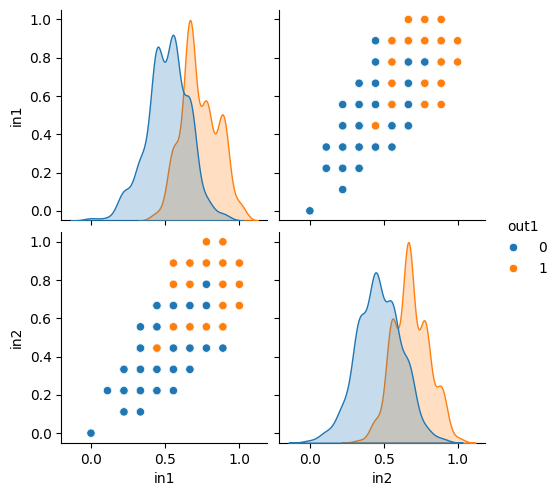

In [7]:
sns.pairplot(df, hue=OUTPUT_label, height=2.5)

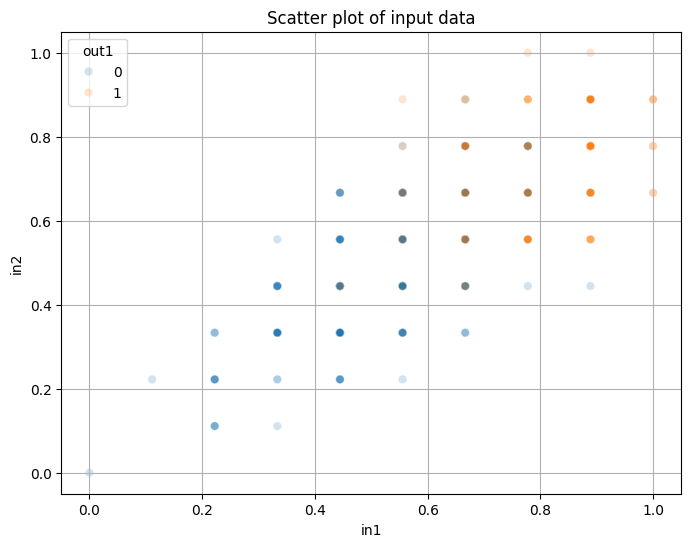

In [7]:
# Plot contour plot of the data.
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=INPUT_label[0], y=INPUT_label[1], hue=OUTPUT_label, alpha=0.2)
plt.title('Scatter plot of input data')
plt.legend(title=OUTPUT_label)
plt.grid(True)
plt.show()


# MODELLING

### UNCONSTRAINED KAN

In [9]:
#### INITIALIZATION OF THE MODEL WITH KAN MODEL ####
import KAN
importlib.reload(KAN)
from KAN import KAN

ini = X_train_tensor.min().item()
fin = X_train_tensor.max().item()

classification = True
hermite = True
seed=0
unconstrained_KAN  = KAN(width=[2,1,1], grid=10,grid_range=[ini,fin], k=-1, 
            noise_scale=0.0,noise_scale_base=0.0, seed=0,grid_eps=0,
            base_fun=nn.Sigmoid(),symbolic_enabled=False,classification=classification,hermite=hermite,
                         device = 'cpu'
                        )

# if hermite:
#     mono_vars = {0:1,1:1}
#     model.apply_constraints_hermite_vectorized(mono_vars)

Classification


Epoch: 609/1000 | train loss: 3.89e-01 | val loss: 4.38e-01 | best val loss: 4.16e-01 | reg: 0.00e+0


Early stopping
Peak memory usage: 28.60 MB
Training time: 6.55 seconds
Memory used during training: 84.29 MB
Train Accuracy 0.7948717948717948
Val Accuracy 0.8076923076923077
Test Accuracy 0.8469387755102041


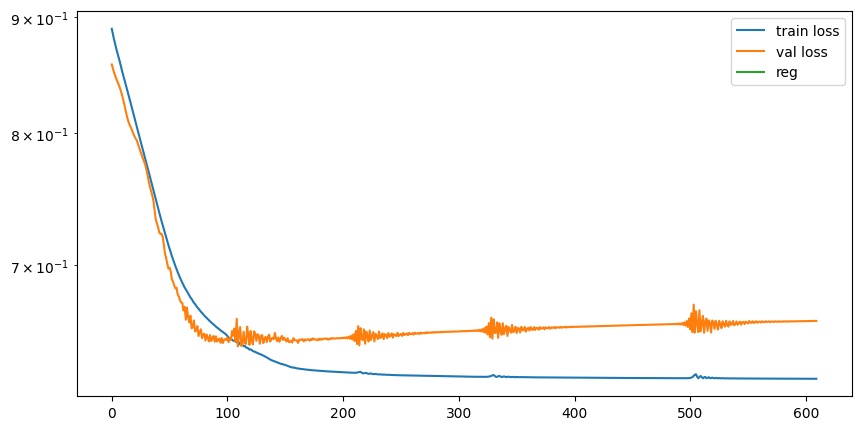

In [10]:
import tracemalloc
# Set random seed
torch.manual_seed(0)

# Select loss function
if classification:
    print('Classification')
    loss_fn = nn.BCELoss()
else:
    print('Regression')
    loss_fn = nn.MSELoss()

# Initialize process
process = psutil.Process(os.getpid())

# Measure time and memory before training
start_time = time.time()
mem_before = process.memory_info().rss / 1024 ** 2  # Memory in MB
tracemalloc.start()

# Train model
unconstrained_KAN.train(
    dataset, 
    opt="Adam", 
    steps=1000, 
    lamb=1.00,
    lamb_l1=0,
    lamb_entropy=0.0,
    small_reg_factor=0,
    lamb_coef=0,
    lamb_coefdiff=0,
    update_grid=False,
    lr=0.01,
    monotonic=False,
    monotonic_vars=[],
    patience=500,
    loss_fn=loss_fn,
    batch=-1
)
current, peak = tracemalloc.get_traced_memory()
print(f"Peak memory usage: {peak / 1024 ** 2:.2f} MB")
tracemalloc.stop()

# Measure time and memory after training
end_time = time.time()
mem_after = process.memory_info().rss / 1024 ** 2  # Memory in MB

print(f"Training time: {end_time - start_time:.2f} seconds")
print(f"Memory used during training: {mem_after - mem_before:.2f} MB")

### Results
if not classification: 
    y_pred = unconstrained_KAN.forward(X_train_tensor)
    print('Train MSE Error',torch.nn.functional.mse_loss(y_pred,y_train_tensor))

    y_pred = unconstrained_KAN.forward(X_val_tensor)
    print('Val MSE Error',torch.nn.functional.mse_loss(y_pred,y_val_tensor))
    
    y_pred = unconstrained_KAN.forward(X_test_tensor)
    print('Test MSE Error',torch.nn.functional.mse_loss(y_pred,y_test_tensor))

else:
    y_pred = unconstrained_KAN.forward(X_train_tensor)
    print('Train Accuracy',accuracy_score(y_train_tensor.detach().numpy(),y_pred.detach().numpy().round()))

    y_pred = unconstrained_KAN.forward(X_val_tensor) 
    print('Val Accuracy',accuracy_score(y_val_tensor.detach().numpy(),y_pred.detach().numpy().round()))

    y_pred = unconstrained_KAN.forward(X_test_tensor) 
    print('Test Accuracy',accuracy_score(y_test_tensor.detach().numpy(),y_pred.detach().numpy().round()))

unconstrained_KAN.plot_history()

The model has 74 parameters.


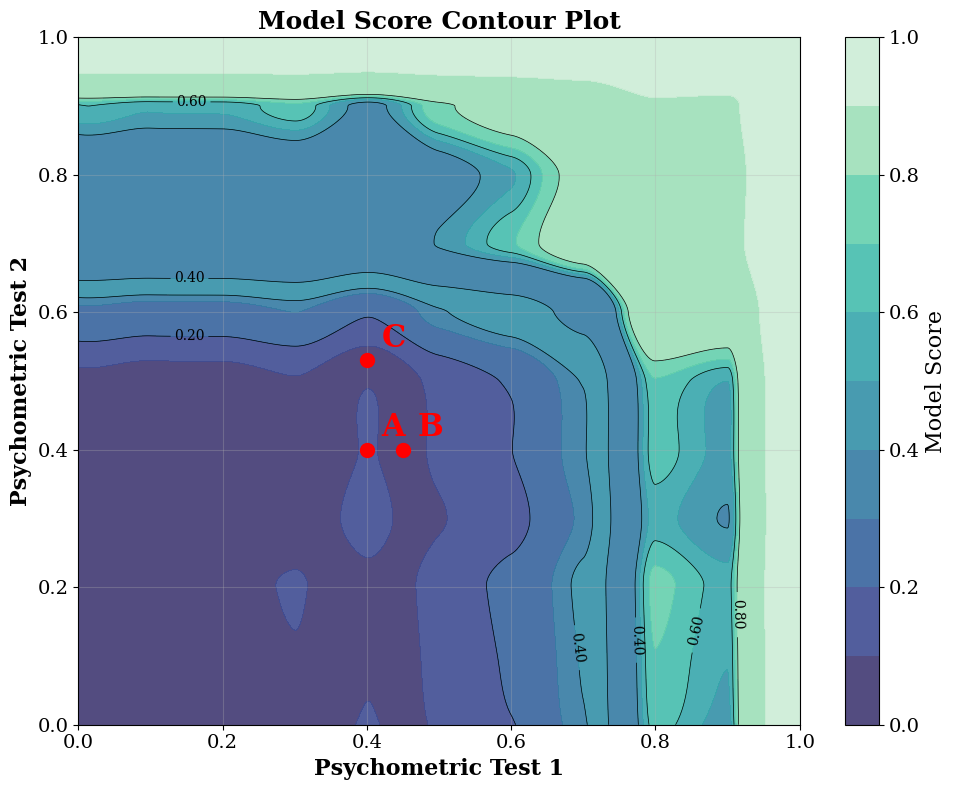

In [35]:
# Plot model contour
points = [(0.4, 0.4),(0.45,0.4),(0.4,0.53)]
num_parameters = utils.count_parameters(unconstrained_KAN)
print(f"The model has {num_parameters} parameters.")
plot_model_contour_torch(unconstrained_KAN,df,INPUT_label[0],INPUT_label[1],
                         num_keypoints=1000,show_points=False,name='Unconstrained',
                        labeled_points = points,
                        labels = ['A','B','C'])

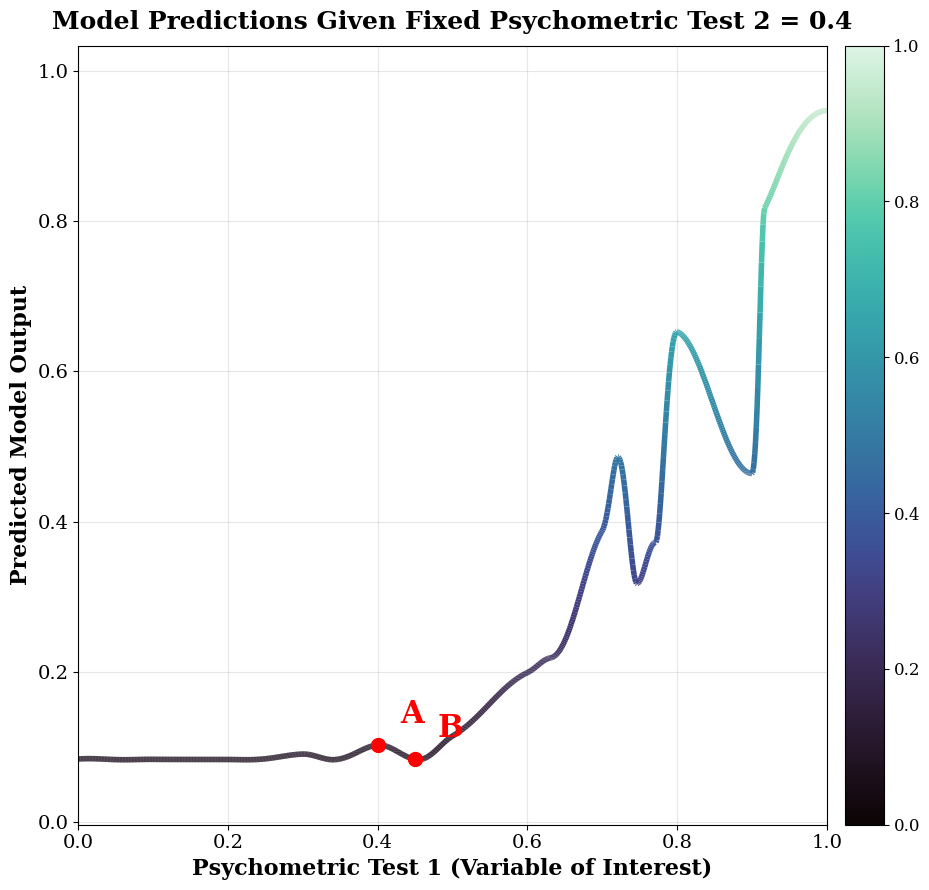

In [46]:
# Example call to plot_model_cut_torch
points = [(0.4, 0.4),(0.45,0.4)]

plot_model_cut_torch(
    model=unconstrained_KAN,  # Replace with your trained model
    df=df,                    # DataFrame containing the data
    var1='in1',              # First variable (e.g., undergraduate GPA)
    var2='in2',              # Second variable (e.g., LSAT score)
    fixed_var='in2',         # Variable to fix ('ugpa' or 'lsat')
    fixed_value=0.4,          # Value to fix the variable to
    num_keypoints=1000,        # Number of points for the plot
    point_alpha=0.6,           # Transparency of the data points
    labeled_points=points,
    labels = ['A','B'],
    name=None
)

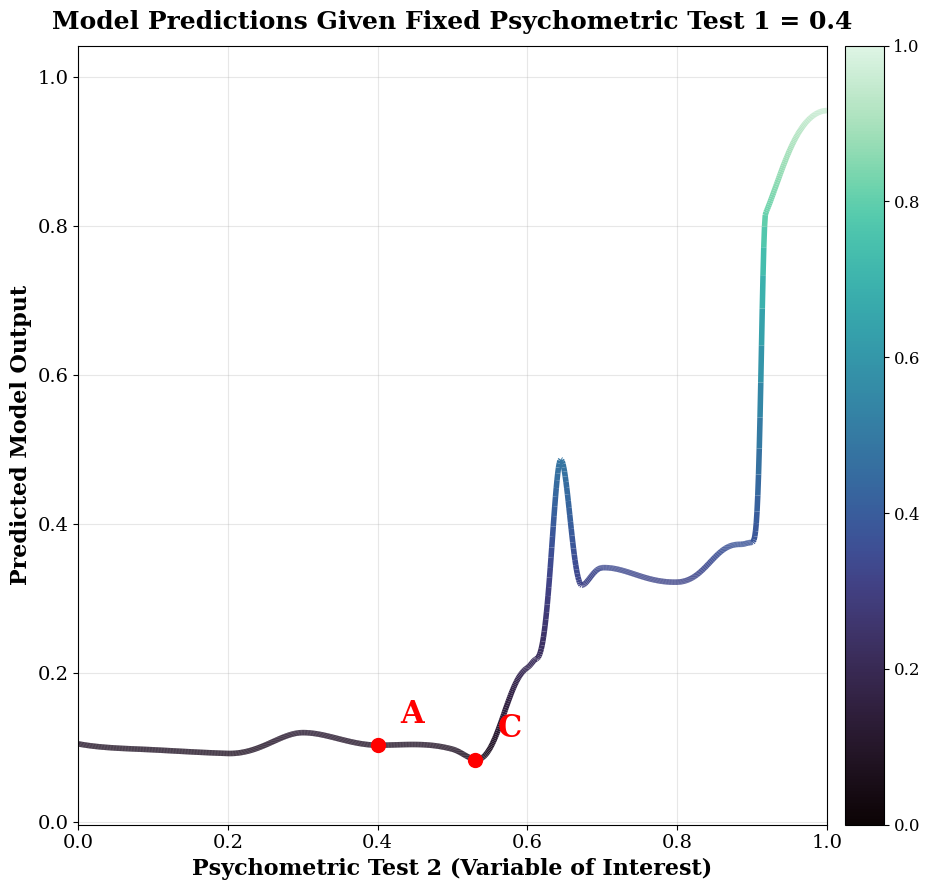

In [47]:
# Example call to plot_model_cut_torch
points = [(0.4, 0.4),(0.4,0.53)]

plot_model_cut_torch(
    model=unconstrained_KAN,  # Replace with your trained model
    df=df,                    # DataFrame containing the data
    var1='in1',              # First variable (e.g., undergraduate GPA)
    var2='in2',              # Second variable (e.g., LSAT score)
    fixed_var='in1',         # Variable to fix ('ugpa' or 'lsat')
    fixed_value=0.4,          # Value to fix the variable to
    num_keypoints=1000,        # Number of points for the plot
    point_alpha=0.6,           # Transparency of the data points
    labeled_points=points,
    labels = ['A','C'],
    name='Unconstrained_Input1'
)

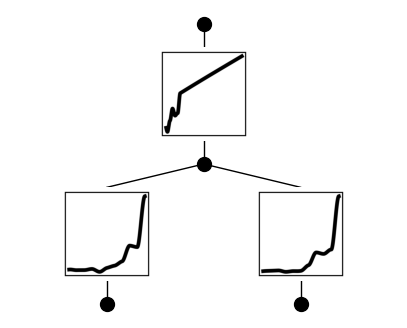

In [12]:
unconstrained_KAN.plot(beta=10000)

### PARTIALLY CONSTRAINED KAN

In [13]:
#### INITIALIZATION OF THE MODEL WITHº KAN MODEL ####
import KAN
importlib.reload(KAN)
from KAN import KAN

ini = X_train_tensor.min().item()
fin = X_train_tensor.max().item()

classification = True
hermite = True
seed=0
partial_MonoKAN = KAN(width=[2,1,1], grid=10,grid_range=[ini,fin], k=-1, 
            noise_scale=0.0,noise_scale_base=0.0, seed=0,grid_eps=0,
            base_fun=nn.Sigmoid(),symbolic_enabled=False,classification=classification,hermite=hermite)

if hermite:
    mono_vars = {0:1,1:0}
    partial_MonoKAN.apply_constraints_hermite_vectorized(mono_vars)

Classification


Epoch: 559/1000 | train loss: 3.89e-01 | val loss: 4.33e-01 | best val loss: 3.95e-01 | reg: 0.00e+0


Early stopping
Train Accuracy 0.7916666666666666
Val Accuracy 0.8076923076923077
Test Accuracy 0.8469387755102041


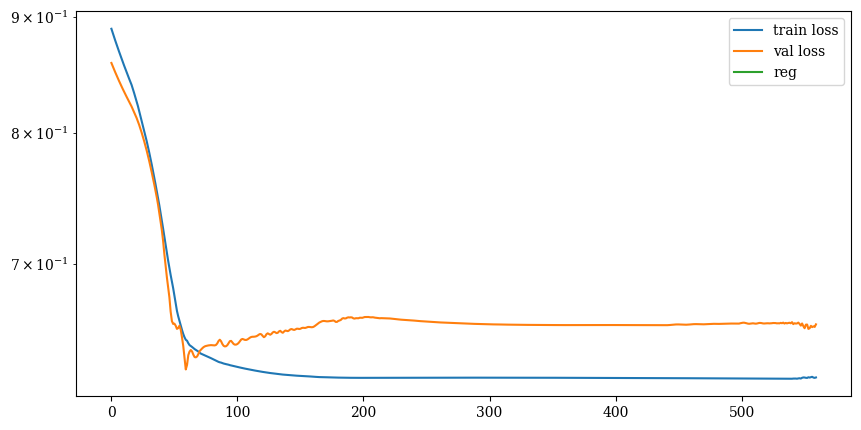

In [14]:
torch.manual_seed(0)
if classification:
    print('Classification')
    loss_fn = nn.BCELoss()
else:
    print('Regression')
    loss_fn = nn.MSELoss()

partial_MonoKAN.train(
    dataset, 
    opt="Adam", 
    steps=1000, 
    lamb=1.00,
    lamb_l1=0,
    lamb_entropy=0.0,
    small_reg_factor=0,
    lamb_coef=0,
    lamb_coefdiff=0,
    update_grid=False,
    lr=0.01,
    monotonic=True,
    monotonic_vars=mono_vars,
    patience=500,
    loss_fn=loss_fn,
    batch=-1
)


### Results
if not classification: 
    y_pred = partial_MonoKAN.forward(X_train_tensor)
    print('Train MSE Error',torch.nn.functional.mse_loss(y_pred,y_train_tensor))

    y_pred = partial_MonoKAN.forward(X_val_tensor)
    print('Val MSE Error',torch.nn.functional.mse_loss(y_pred,y_val_tensor))
    
    y_pred = partial_MonoKAN.forward(X_test_tensor)
    print('Test MSE Error',torch.nn.functional.mse_loss(y_pred,y_test_tensor))

else:
    y_pred = partial_MonoKAN.forward(X_train_tensor)
    print('Train Accuracy',accuracy_score(y_train_tensor.detach().numpy(),y_pred.detach().numpy().round()))

    y_pred = partial_MonoKAN.forward(X_val_tensor) 
    print('Val Accuracy',accuracy_score(y_val_tensor.detach().numpy(),y_pred.detach().numpy().round()))

    y_pred = partial_MonoKAN.forward(X_test_tensor) 
    print('Test Accuracy',accuracy_score(y_test_tensor.detach().numpy(),y_pred.detach().numpy().round()))

partial_MonoKAN.plot_history()

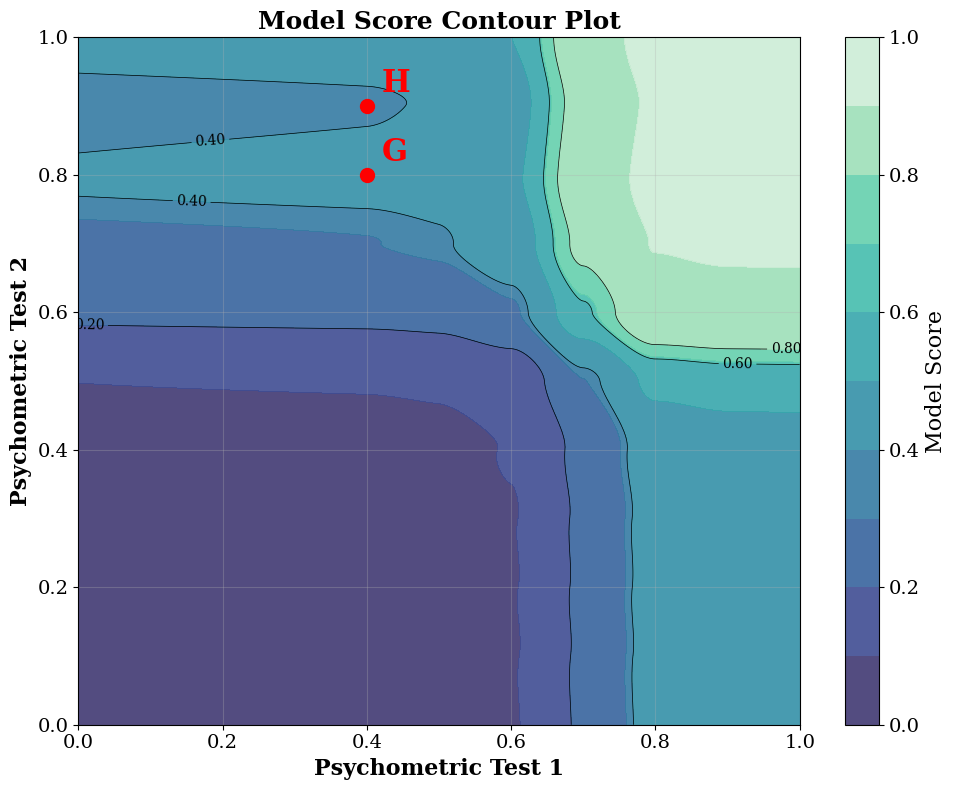

In [28]:
# Plot model contour
points = [(0.4, 0.8),(0.4,0.9)]
plot_model_contour_torch(partial_MonoKAN,df,INPUT_label[0],INPUT_label[1],
                         num_keypoints=1000,show_points=False,name='Monotonic_Input1',
                        labeled_points = points,
                        labels = ['G','H'] )

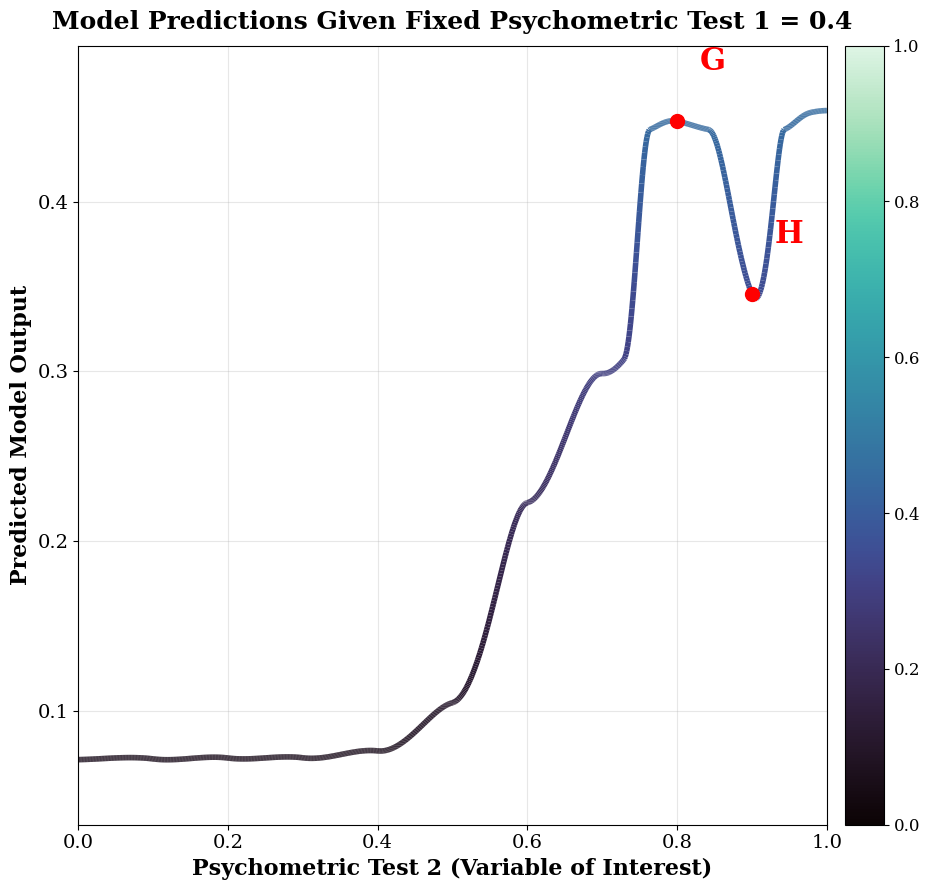

In [73]:
# Example call to plot_model_cut_torch
points = [(0.4, 0.8),(0.4,0.9)]

plot_model_cut_torch(
    model=partial_MonoKAN,  # Replace with your trained model
    df=df,                    # DataFrame containing the data
    var1='in1',              # First variable (e.g., undergraduate GPA)
    var2='in2',              # Second variable (e.g., LSAT score)
    fixed_var='in1',         # Variable to fix ('ugpa' or 'lsat')
    fixed_value=0.4,          # Value to fix the variable to
    num_keypoints=1000,        # Number of points for the plot
    name=None,    # Name for saving the plot (optional)
    point_alpha=0.6,           # Transparency of the data points
    labeled_points=points,
    labels = ['G','H']

)

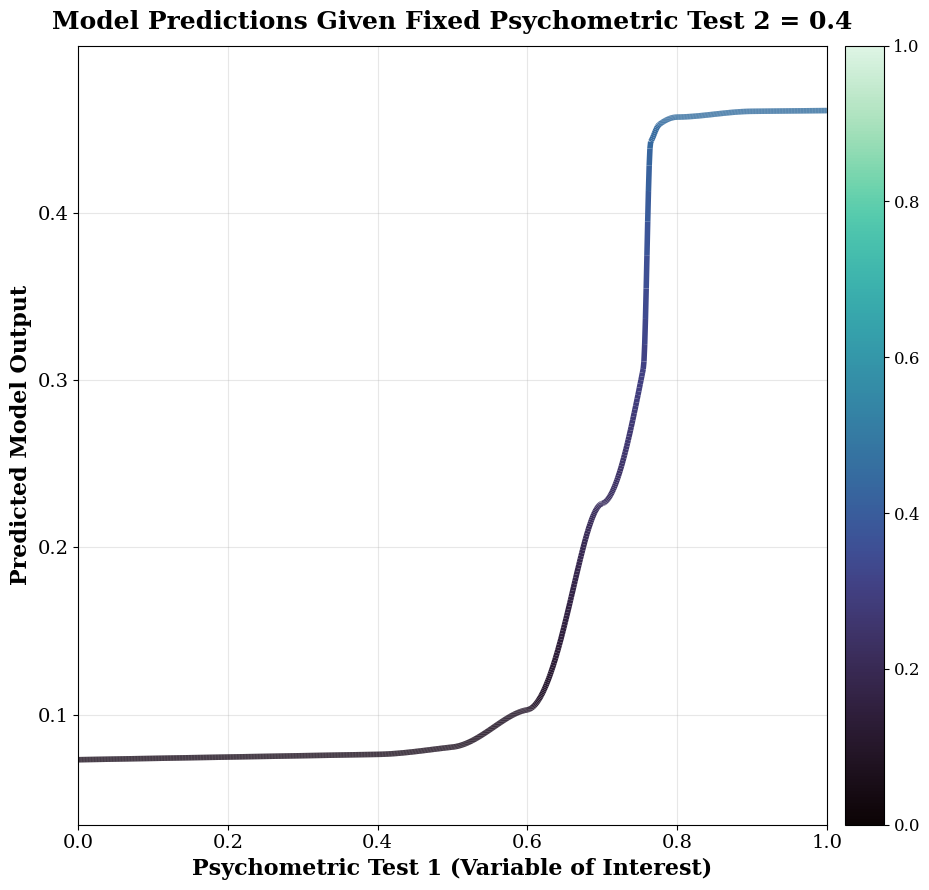

In [53]:
# Example call to plot_model_cut_torch
points = [(0.4, 0.8),(0.4,0.9)]

plot_model_cut_torch(
    model=partial_MonoKAN,  # Replace with your trained model
    df=df,                    # DataFrame containing the data
    var1='in1',              # First variable (e.g., undergraduate GPA)
    var2='in2',              # Second variable (e.g., LSAT score)
    fixed_var='in2',         # Variable to fix ('ugpa' or 'lsat')
    fixed_value=0.4,          # Value to fix the variable to
    num_keypoints=1000,        # Number of points for the plot
    name=None,    # Name for saving the plot (optional)
    point_alpha=0.6,           # Transparency of the data points
    labeled_points=None,
    labels = ['D','E']

)

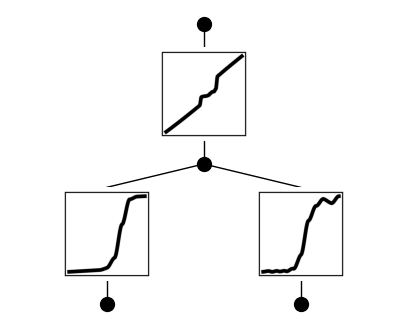

In [121]:
partial_MonoKAN.plot(beta=1000)

### MONOKAN

In [18]:
#### INITIALIZATION OF THE MODEL WITHº KAN MODEL ####
import KAN
importlib.reload(KAN)
from KAN import KAN

ini = X_train_tensor.min().item()
fin = X_train_tensor.max().item()

classification = True
hermite = True
seed=0
monoKAN = KAN(width=[2,1,1], grid=10,grid_range=[ini,fin], k=-1, 
            noise_scale=0.0,noise_scale_base=0.0, seed=0,grid_eps=0,
            base_fun=nn.Sigmoid(),symbolic_enabled=False,classification=classification,hermite=hermite)

if hermite:
    mono_vars = {0:1,1:1}
    monoKAN.apply_constraints_hermite_vectorized(mono_vars)

Classification


Epoch: 559/1000 | train loss: 3.93e-01 | val loss: 4.32e-01 | best val loss: 3.95e-01 | reg: 0.00e+0


Early stopping
Peak memory usage: 0.59 MB
Training time: 5.14 seconds
Memory used during training: 0.05 MB
Train Accuracy 0.7916666666666666
Val Accuracy 0.8076923076923077
Test Accuracy 0.8469387755102041


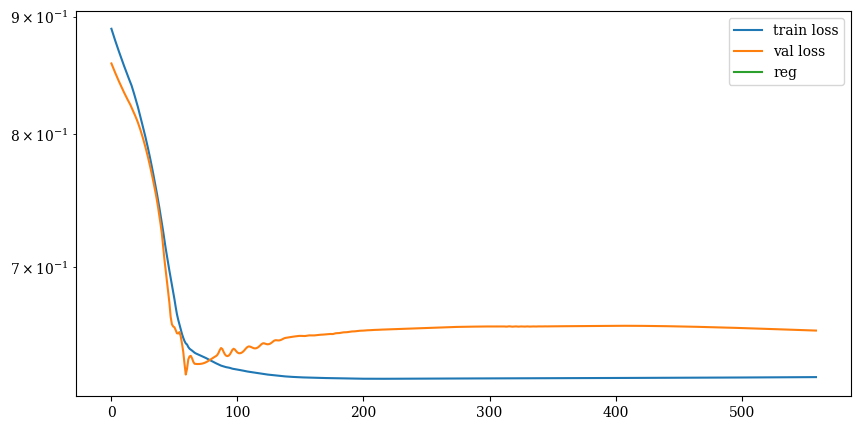

In [19]:
import tracemalloc
# Set random seed
torch.manual_seed(0)

# Select loss function
if classification:
    print('Classification')
    loss_fn = nn.BCELoss()
else:
    print('Regression')
    loss_fn = nn.MSELoss()

# Initialize process
process = psutil.Process(os.getpid())

# Measure time and memory before training
start_time = time.time()
mem_before = process.memory_info().rss / 1024 ** 2  # Memory in MB
tracemalloc.start()

# Train model
monoKAN.train(
    dataset, 
    opt="Adam", 
    steps=1000, 
    lamb=1.00,
    lamb_l1=0,
    lamb_entropy=0.0,
    small_reg_factor=0,
    lamb_coef=0,
    lamb_coefdiff=0,
    update_grid=False,
    lr=0.01,
    monotonic=True,
    monotonic_vars=mono_vars,
    patience=500,
    loss_fn=loss_fn,
    batch=-1
)
current, peak = tracemalloc.get_traced_memory()
print(f"Peak memory usage: {peak / 1024 ** 2:.2f} MB")
tracemalloc.stop()

# Measure time and memory after training
end_time = time.time()
mem_after = process.memory_info().rss / 1024 ** 2  # Memory in MB

print(f"Training time: {end_time - start_time:.2f} seconds")
print(f"Memory used during training: {mem_after - mem_before:.2f} MB")

### Results
if not classification: 
    y_pred = monoKAN.forward(X_train_tensor)
    print('Train MSE Error',torch.nn.functional.mse_loss(y_pred,y_train_tensor))

    y_pred = monoKAN.forward(X_val_tensor)
    print('Val MSE Error',torch.nn.functional.mse_loss(y_pred,y_val_tensor))
    
    y_pred = monoKAN.forward(X_test_tensor)
    print('Test MSE Error',torch.nn.functional.mse_loss(y_pred,y_test_tensor))

else:
    y_pred = monoKAN.forward(X_train_tensor)
    print('Train Accuracy',accuracy_score(y_train_tensor.detach().numpy(),y_pred.detach().numpy().round()))

    y_pred = monoKAN.forward(X_val_tensor) 
    print('Val Accuracy',accuracy_score(y_val_tensor.detach().numpy(),y_pred.detach().numpy().round()))

    y_pred = monoKAN.forward(X_test_tensor) 
    print('Test Accuracy',accuracy_score(y_test_tensor.detach().numpy(),y_pred.detach().numpy().round()))

monoKAN.plot_history()

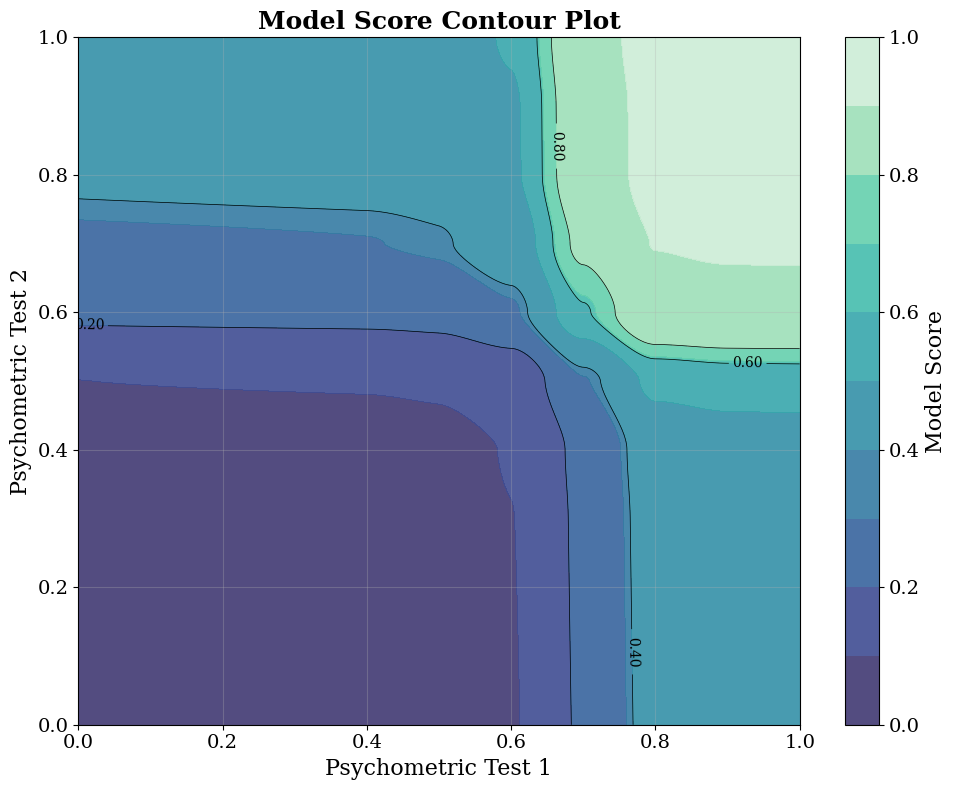

In [56]:
# Plot model contour 
plot_model_contour_torch(monoKAN,df,INPUT_label[0],INPUT_label[1], num_keypoints=1000,show_points=False,name='Monotonic_Input1_and_Input2')

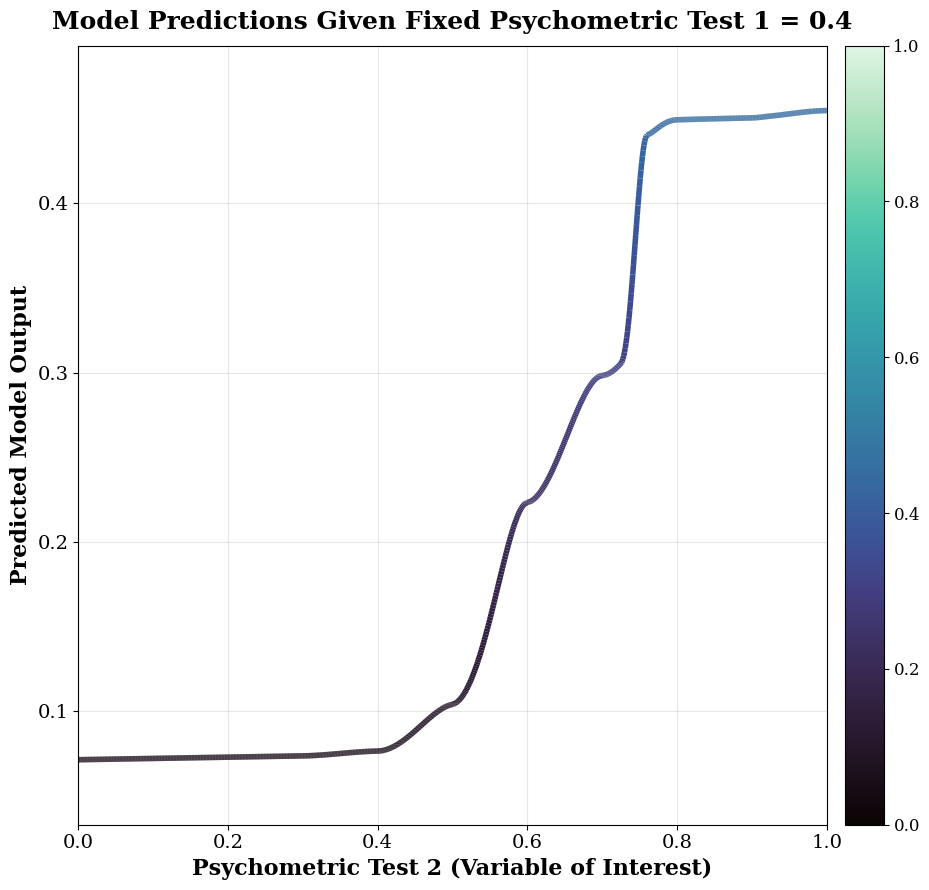

In [21]:
# Example call to plot_model_cut_torch
points = [(0.4, 0.8),(0.4,0.9)]

plot_model_cut_torch(
    model=monoKAN,  # Replace with your trained model
    df=df,                    # DataFrame containing the data
    var1='in1',              # First variable (e.g., undergraduate GPA)
    var2='in2',              # Second variable (e.g., LSAT score)
    fixed_var='in1',         # Variable to fix ('ugpa' or 'lsat')
    fixed_value=0.4,          # Value to fix the variable to
    num_keypoints=1000,        # Number of points for the plot
    name=None,    # Name for saving the plot (optional)
    point_alpha=0.6,           # Transparency of the data points
    labeled_points=None,
    labels = ['D','E']

)

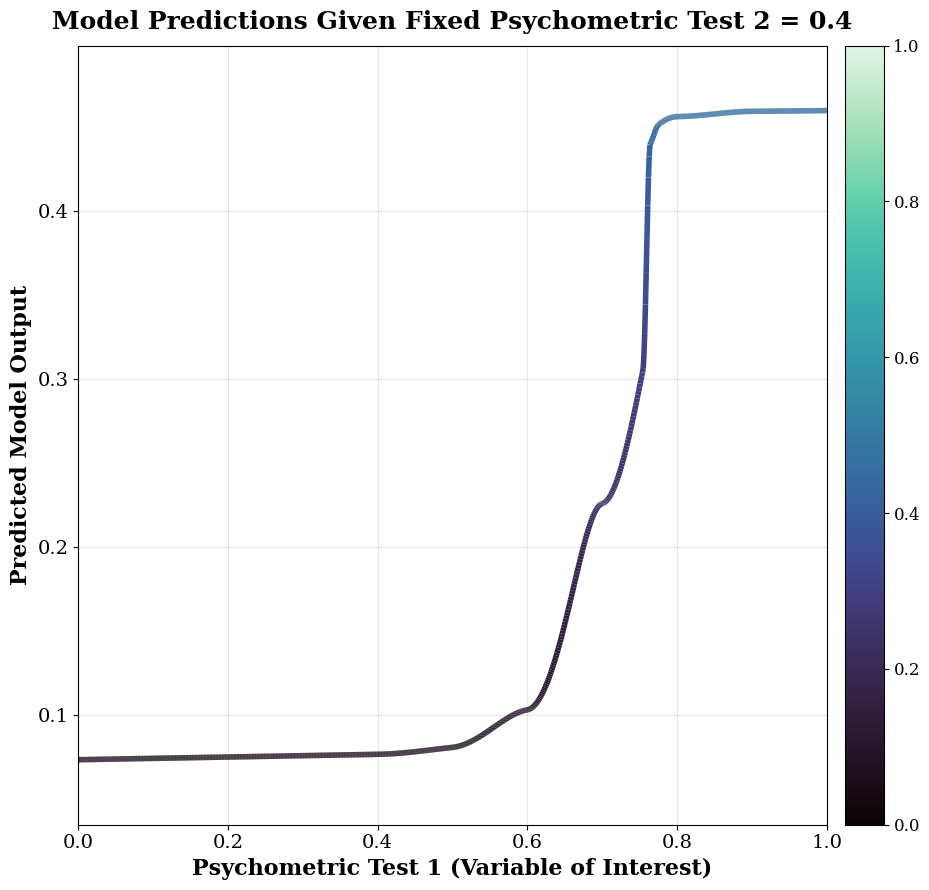

In [22]:
# Example call to plot_model_cut_torch
points = [(0.4, 0.8),(0.4,0.9)]

plot_model_cut_torch(
    model=monoKAN,  # Replace with your trained model
    df=df,                    # DataFrame containing the data
    var1='in1',              # First variable (e.g., undergraduate GPA)
    var2='in2',              # Second variable (e.g., LSAT score)
    fixed_var='in2',         # Variable to fix ('ugpa' or 'lsat')
    fixed_value=0.4,          # Value to fix the variable to
    num_keypoints=1000,        # Number of points for the plot
    name=None,    # Name for saving the plot (optional)
    point_alpha=0.6,           # Transparency of the data points
    labeled_points=None,
    labels = ['D','E']

)

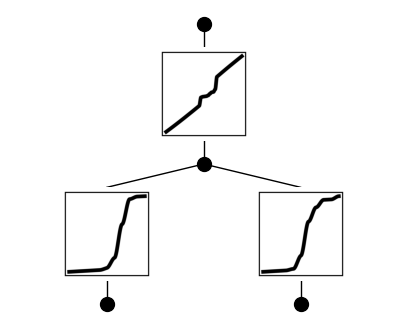

In [125]:
monoKAN.plot(beta=1000)

### PYKAN

In [24]:
#### INITIALIZATION OF THE MODEL WITHº KAN MODEL ####
import KAN
importlib.reload(KAN)
from KAN import KAN

ini = X_train_tensor.min().item()
fin = X_train_tensor.max().item()

classification = True
hermite = False
seed=0
KAN = KAN(width=[2,1,1], grid=10,grid_range=[ini,fin], k=3, 
            noise_scale=0.0,noise_scale_base=0.0, seed=0,grid_eps=0,
            base_fun=nn.Sigmoid(),symbolic_enabled=False,classification=classification,hermite=hermite)

Classification


Epoch: 592/1000 | train loss: 3.86e-01 | val loss: 5.22e-01 | best val loss: 4.50e-01 | reg: 0.00e+0


Early stopping
Peak memory usage: 0.58 MB
Training time: 6.98 seconds
Memory used during training: 0.69 MB
Train Accuracy 0.8012820512820513
Val Accuracy 0.8333333333333334
Test Accuracy 0.8469387755102041


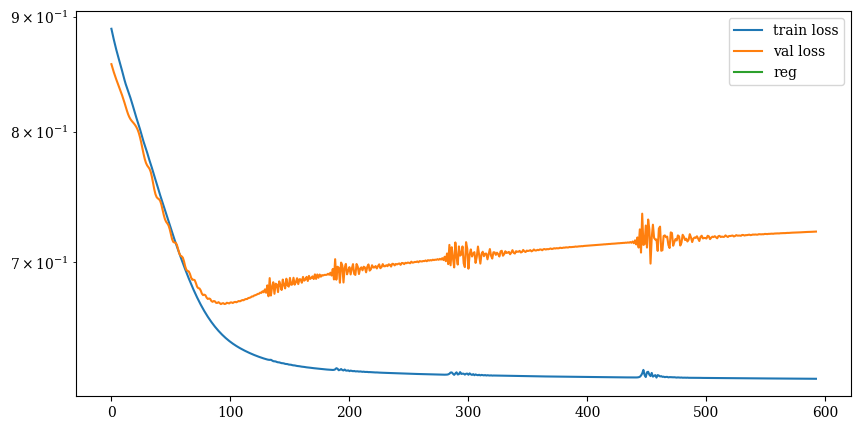

In [25]:
import tracemalloc
# Set random seed
torch.manual_seed(0)

# Select loss function
if classification:
    print('Classification')
    loss_fn = nn.BCELoss()
else:
    print('Regression')
    loss_fn = nn.MSELoss()

# Initialize process
process = psutil.Process(os.getpid())

# Measure time and memory before training
start_time = time.time()
mem_before = process.memory_info().rss / 1024 ** 2  # Memory in MB
tracemalloc.start()

# Train model
KAN.train(
    dataset, 
    opt="Adam", 
    steps=1000, 
    lamb=1.00,
    lamb_l1=0,
    lamb_entropy=0.0,
    small_reg_factor=0,
    lamb_coef=0,
    lamb_coefdiff=0,
    update_grid=False,
    lr=0.01,
    monotonic=False,
    monotonic_vars=[],
    patience=500,
    loss_fn=loss_fn,
    batch=-1
)
current, peak = tracemalloc.get_traced_memory()
print(f"Peak memory usage: {peak / 1024 ** 2:.2f} MB")
tracemalloc.stop()

# Measure time and memory after training
end_time = time.time()
mem_after = process.memory_info().rss / 1024 ** 2  # Memory in MB

print(f"Training time: {end_time - start_time:.2f} seconds")
print(f"Memory used during training: {mem_after - mem_before:.2f} MB")



### Results
if not classification: 
    y_pred = KAN.forward(X_train_tensor)
    print('Train MSE Error',torch.nn.functional.mse_loss(y_pred,y_train_tensor))

    y_pred = KAN.forward(X_val_tensor)
    print('Val MSE Error',torch.nn.functional.mse_loss(y_pred,y_val_tensor))
    
    y_pred = KAN.forward(X_test_tensor)
    print('Test MSE Error',torch.nn.functional.mse_loss(y_pred,y_test_tensor))

else:
    y_pred = KAN.forward(X_train_tensor)
    print('Train Accuracy',accuracy_score(y_train_tensor.detach().numpy(),y_pred.detach().numpy().round()))

    y_pred = KAN.forward(X_val_tensor) 
    print('Val Accuracy',accuracy_score(y_val_tensor.detach().numpy(),y_pred.detach().numpy().round()))

    y_pred = KAN.forward(X_test_tensor) 
    print('Test Accuracy',accuracy_score(y_test_tensor.detach().numpy(),y_pred.detach().numpy().round()))

KAN.plot_history()

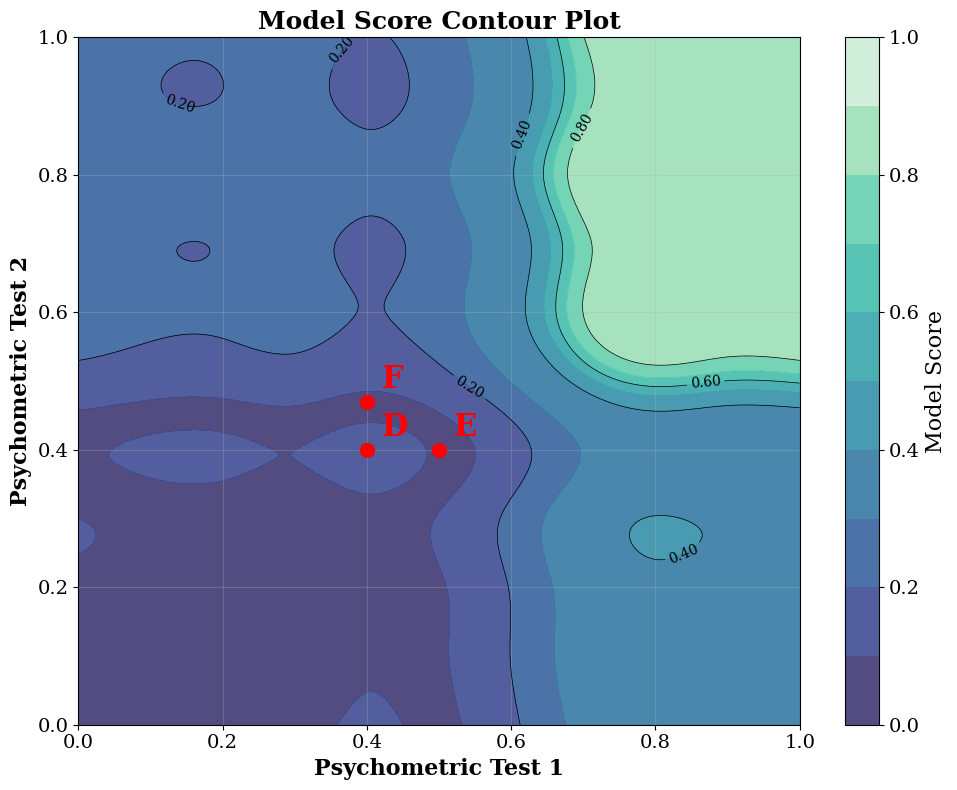

In [37]:
# Plot model contour
points = [(0.4, 0.4),(0.4, 0.47),(0.5, 0.4)]

plot_model_contour_torch(KAN,df,INPUT_label[0],INPUT_label[1],
                         num_keypoints=1000,show_points=False,
                        labeled_points = points, labels = ['D','F','E'], name = 'KAN_BSplines')


# # Plot model contour
# points = [(0.4, 0.8),(0.4,0.9)]
# plot_model_contour_torch(partial_MonoKAN,df,INPUT_label[0],INPUT_label[1],
#                          num_keypoints=1000,show_points=False,name='Monotonic_Input1',
#                         labeled_points = points,
#                         labels = ['D','E'] )

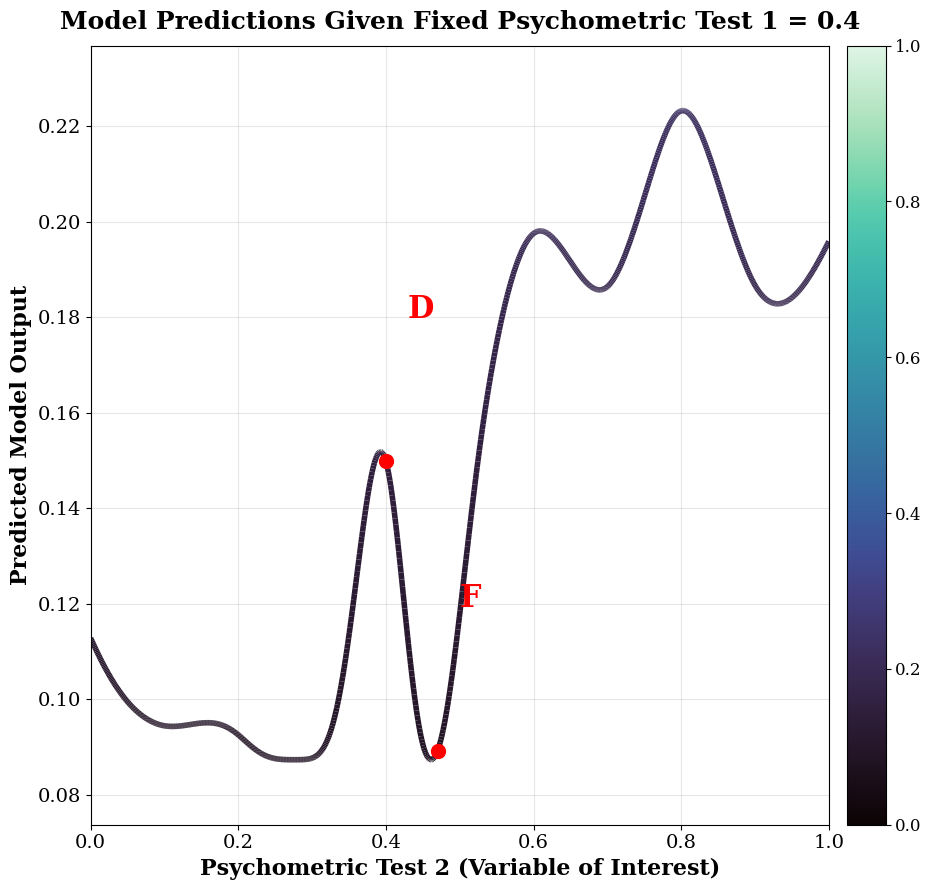

In [76]:
# Example call to plot_model_cut_torch
points = [(0.4, 0.4),(0.4, 0.47)]

plot_model_cut_torch(
    model=KAN,  # Replace with your trained model
    df=df,                    # DataFrame containing the data
    var1='in1',              # First variable (e.g., undergraduate GPA)
    var2='in2',              # Second variable (e.g., LSAT score)
    fixed_var='in1',         # Variable to fix ('ugpa' or 'lsat')
    fixed_value=0.4,          # Value to fix the variable to
    num_keypoints=1000,        # Number of points for the plot
    name=None,    # Name for saving the plot (optional)
    point_alpha=0.6,           # Transparency of the data points
    labeled_points=points,
    labels = ['D','F']

)

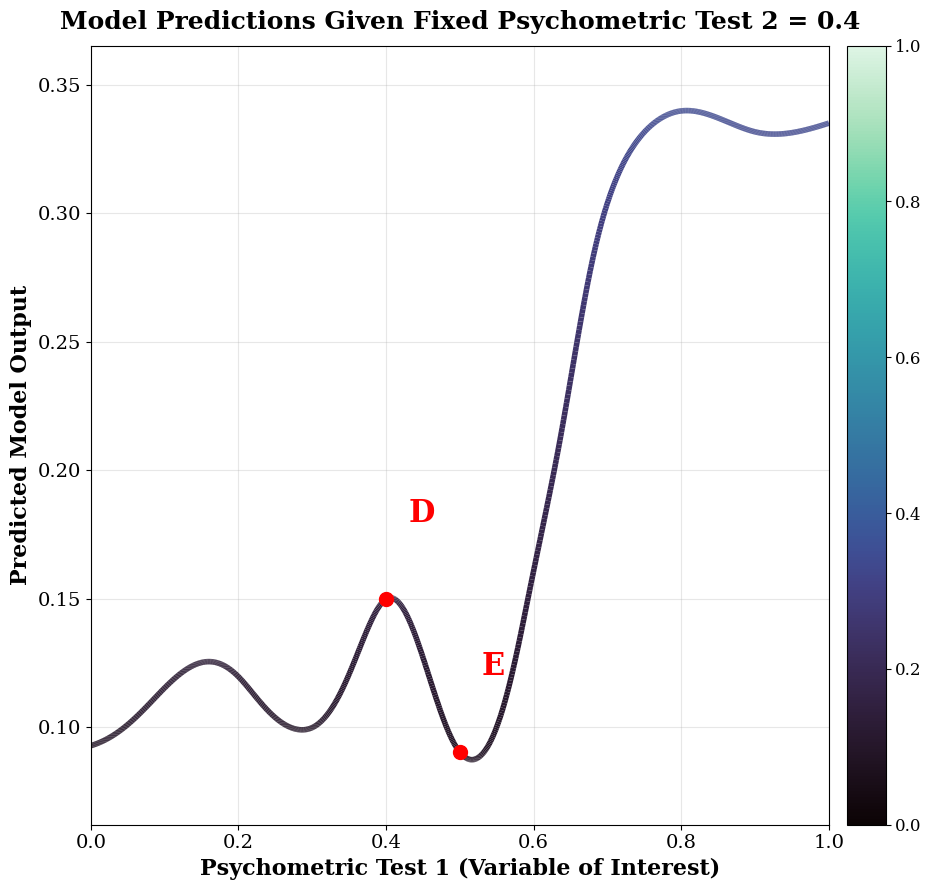

In [77]:
# Example call to plot_model_cut_torch
points = [(0.4, 0.4),(0.5, 0.4)]

plot_model_cut_torch(
    model=KAN,  # Replace with your trained model
    df=df,                    # DataFrame containing the data
    var1='in1',              # First variable (e.g., undergraduate GPA)
    var2='in2',              # Second variable (e.g., LSAT score)
    fixed_var='in2',         # Variable to fix ('ugpa' or 'lsat')
    fixed_value=0.4,          # Value to fix the variable to
    num_keypoints=1000,        # Number of points for the plot
    name=None,    # Name for saving the plot (optional)
    point_alpha=0.6,           # Transparency of the data points
    labeled_points=points,
    labels = ['D','E']

)

In [33]:
# Print the number of parameters, the name and the parameters
for name, param in KAN.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

biases.0.weight torch.Size([1, 1])
biases.1.weight torch.Size([1, 1])
act_fun.0.coef torch.Size([2, 13])
act_fun.0.scale_base torch.Size([2])
act_fun.0.scale_sp torch.Size([2])
act_fun.1.coef torch.Size([1, 13])
act_fun.1.scale_base torch.Size([1])
act_fun.1.scale_sp torch.Size([1])
symbolic_fun.0.affine torch.Size([1, 2, 4])
symbolic_fun.1.affine torch.Size([1, 1, 4])


In [41]:
# Print the number of parameters, the name and the parameters
for name, param in unconstrained_KAN.named_parameters():
    if param.requires_grad and param.grad is not None:
        print(name, param.shape)

biases.0.weight torch.Size([1, 1])
biases.1.weight torch.Size([1, 1])
act_fun.0.coef torch.Size([2, 11, 2])
act_fun.0.scale_base torch.Size([2])
act_fun.0.scale_sp torch.Size([2])
act_fun.1.coef torch.Size([1, 11, 2])
act_fun.1.scale_base torch.Size([1])
act_fun.1.scale_sp torch.Size([1])


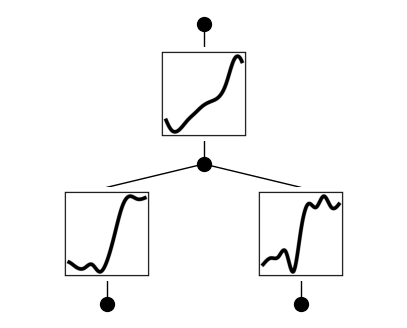

In [134]:
KAN.plot(beta=1000)

### TRAINING COMPARATIVE

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch
import psutil
import numpy as np
import os
import utils
from KAN import KAN
import torch.nn as nn  # Ensure nn is imported

# Define width configurations for grid search
width_configs = [
    [2, 2, 1],
    [2, 5, 1],
    [2, 10, 1],
    [2, 2, 2, 1],
    [2, 5, 2, 1],
    [2, 10, 2, 1],
    [2, 10, 5, 1],
    [2, 10, 10, 1],
    [2, 2, 2, 2, 1],
    [2, 2, 5, 5, 1],
    [2, 2, 10, 5, 1],
]

# Initialize results list
results = []
classification = True
n_epochs = 10  # Number of epochs for training

# Loop through both hermite and monotonic configurations
for hermite in [False, True]:
    for monotonic in [True, False]:

        # Skip invalid combination: monotonic=True requires hermite=True
        if monotonic and not hermite:
            continue

        for width in width_configs:
            print(f"Testing width configuration: {width} | hermite={hermite} | monotonic={monotonic}")
            
            training_times_per_epoch = []

            for seed in range(5):  # Repeat each experiment 5 times
                # Initialize the model
                monoKAN = KAN(
                    width=width, grid=3, grid_range=[ini, fin], k=5,
                    noise_scale=0.0, noise_scale_base=0.0, seed=seed, grid_eps=0,
                    base_fun=nn.Sigmoid(), symbolic_enabled=False,
                    classification=classification, hermite=hermite
                )

                # Apply monotonic constraints only when hermite is True and monotonic is True
                if monotonic:
                    mono_vars = {0: 1, 1: 1}
                    monoKAN.apply_constraints_hermite_vectorized(mono_vars)
                else:
                    mono_vars = []

                # Measure time before training
                start_time = time.time()

                # Train the model
                monoKAN.train(
                    dataset,
                    opt="Adam",
                    steps=n_epochs,
                    lamb=1.00,
                    lamb_l1=0,
                    lamb_entropy=0.0,
                    small_reg_factor=0,
                    lamb_coef=0,
                    lamb_coefdiff=0,
                    update_grid=False,
                    lr=0.01,
                    monotonic=monotonic,
                    monotonic_vars=mono_vars,
                    patience=n_epochs,
                    loss_fn=loss_fn,
                    batch=-1
                )

                # Measure time after training
                end_time = time.time()
                total_training_time = end_time - start_time
                training_time_per_epoch = total_training_time / n_epochs
                training_times_per_epoch.append(training_time_per_epoch)

            # Calculate mean and std dev of training times per epoch
            mean_training_time_per_epoch = np.mean(training_times_per_epoch)
            std_training_time_per_epoch = np.std(training_times_per_epoch)
            num_parameters = utils.count_parameters(monoKAN)

            # Save results
            results.append({
                "width": width,
                "num_parameters": num_parameters,
                "mean_training_time_per_epoch": mean_training_time_per_epoch,
                "std_training_time_per_epoch": std_training_time_per_epoch,
                "monotonic": monotonic,
                "hermite": hermite
            })


Testing width configuration: [2, 2, 1] | hermite=False | monotonic=False


Epoch: 9/10 | train loss: 7.46e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.46e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.46e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.46e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.46e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1


Testing width configuration: [2, 5, 1] | hermite=False | monotonic=False


Epoch: 9/10 | train loss: 7.57e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.57e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.57e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.57e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.57e-01 | val loss: 7.06e-01 | best val loss: 7.06e-01 | reg: 0.00e+00: 1


Testing width configuration: [2, 10, 1] | hermite=False | monotonic=False


...

Epoch: 9/10 | train loss: 7.67e-01 | val loss: 7.22e-01 | best val loss: 7.22e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.67e-01 | val loss: 7.22e-01 | best val loss: 7.22e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.67e-01 | val loss: 7.22e-01 | best val loss: 7.22e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.67e-01 | val loss: 7.22e-01 | best val loss: 7.22e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 7.67e-01 | val loss: 7.22e-01 | best val loss: 7.22e-01 | reg: 0.00e+00: 1


Testing width configuration: [2, 2, 5, 5, 1] | hermite=True | monotonic=False


Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.37e-01 | best val loss: 7.37e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.37e-01 | best val loss: 7.37e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.37e-01 | best val loss: 7.37e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.37e-01 | best val loss: 7.37e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.37e-01 | best val loss: 7.37e-01 | reg: 0.00e+00: 1


Testing width configuration: [2, 2, 10, 5, 1] | hermite=True | monotonic=False


Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.35e-01 | best val loss: 7.35e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.35e-01 | best val loss: 7.35e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.35e-01 | best val loss: 7.35e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.35e-01 | best val loss: 7.35e-01 | reg: 0.00e+00: 1
Epoch: 9/10 | train loss: 8.03e-01 | val loss: 7.35e-01 | best val loss: 7.35e-01 | reg: 0.00e+00: 1


In [41]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Save results to a CSV file
results_df.to_csv("grid_search_results_mono_comparison.csv", index=False)

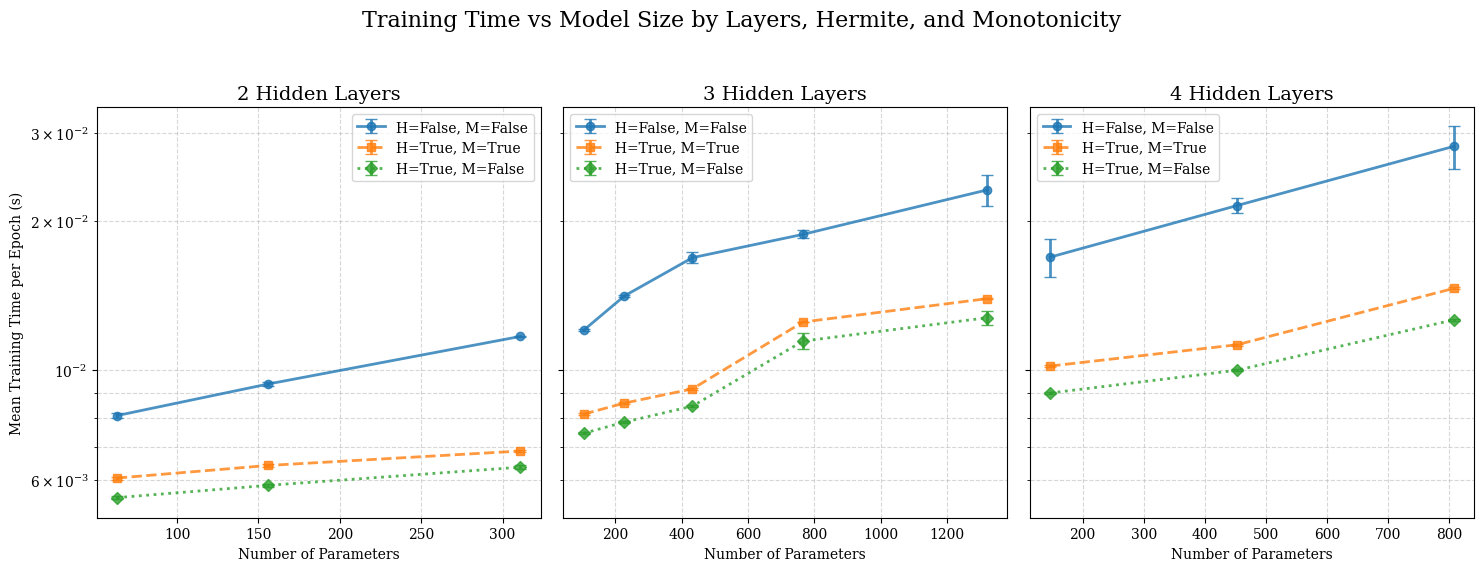

In [42]:
import matplotlib.pyplot as plt

# Ensure 'num_layers' column exists
results_df["num_layers"] = results_df["width"].apply(lambda w: len(w) - 1)
unique_layers = sorted(results_df["num_layers"].unique())
n_layers = len(unique_layers)

# Set up subplots: one horizontal subplot per number of layers
fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 6), sharey=True)

# Set global style
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6
})

colors = plt.cm.tab10.colors
markers = ['o', 's', 'D']
linestyles = ['-', '--', ':']  # To help distinguish all three configs

# Plot for each number of layers
for idx, num_layers in enumerate(unique_layers):
    ax = axes[idx] if n_layers > 1 else axes
    subset = results_df[results_df["num_layers"] == num_layers]

    # Define valid configuration combinations
    configs = [
        {"hermite": False, "monotonic": False},
        {"hermite": True, "monotonic": True},
        {"hermite": True, "monotonic": False},
    ]

    for i, config in enumerate(configs):
        group = subset[
            (subset["hermite"] == config["hermite"]) &
            (subset["monotonic"] == config["monotonic"])
        ]

        if group.empty:
            continue

        group = group.sort_values("num_parameters")
        label = f"H={config['hermite']}, M={config['monotonic']}"
        marker = markers[i % len(markers)]
        color = colors[i % len(colors)]
        linestyle = linestyles[i % len(linestyles)]

        ax.errorbar(
            group["num_parameters"],
            group["mean_training_time_per_epoch"],
            yerr=group["std_training_time_per_epoch"],
            label=label,
            fmt=marker,
            linestyle=linestyle,
            color=color,
            capsize=4,
            alpha=0.8
        )

    ax.set_title(f"{num_layers} Hidden Layer{'s' if num_layers > 1 else ''}")
    ax.set_xlabel("Number of Parameters")
    if idx == 0:
        ax.set_ylabel("Mean Training Time per Epoch (s)")
    ax.set_yscale("log")
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend()

plt.suptitle("Training Time vs Model Size by Layers, Hermite, and Monotonicity", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
